# Exam Score Prediction using Linear Regression

## Objective

The objective of this project is to predict students' final exam scores (G3) using machine learning. The project includes data cleaning, exploratory data analysis (EDA), data preprocessing, model building using Linear Regression, and model evaluation.

# Step 1: Import Libraries

In this step, we import all the Python libraries required for data manipulation, visualization, and machine learning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset

The student performance dataset is loaded into a pandas DataFrame for analysis.

In [3]:
#to import files in google colab
from google.colab import files
uploaded=files.upload()

Saving student_data.csv.xlsx to student_data.csv.xlsx


In [4]:
#to load the the dataset create a variable then upload using pd.read_excel
#here we are using read_excel since it is an excel file if csv then read_csv
df=pd.read_excel("student_data.csv.xlsx")

# Step 3: Dataset Overview

Understanding the dataset by checking its dimensions, data types, and statistical summary.

In [5]:
#to check atleast 6 rows of the dataset
df.head(6)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15


In [6]:
#to check number of rows and columns in the dataset
df.shape

(395, 33)

In [7]:
#To check all column names
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [81]:
df.describe()

,sex,age,address,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,...,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.473418,16.696203,0.777215,2.749367,2.521519,1.448101,2.035443,0.334177,0.129114,0.612658,...,0.949367,0.832911,3.944304,3.235443,3.108861,3.554430,5.708861,10.908861,10.713924,10.415190
std,0.499926,1.276043,0.416643,1.094735,1.088201,0.697505,0.839240,0.743651,0.335751,0.487761,...,0.219525,0.373528,0.896659,0.998862,1.113278,1.390303,8.003096,3.319195,3.761505,4.581443
min,0.000000,15.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,16.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,4.000000,3.000000,2.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,0.000000,17.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000,0.000000,1.000000,...,1.000000,1.000000,4.000000,3.000000,3.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,1.000000,18.000000,1.000000,4.000000,3.000000,2.000000,2.000000,0.000000,0.000000,1.000000,...,1.000000,1.000000,5.000000,4.000000,4.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,1.000000,22.000000,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


# Step 4: Data Cleaning

The dataset was checked for unnecessary columns, missing values, and duplicate records before analysis.

In [8]:
#Data preprocessing
#checking dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [9]:
#checking missing values
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [10]:
#therefore the dataset does not contain any null or missing values

In [11]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

In [16]:
#Removing unnecessary columns
columns_to_drop=['school','famsize','Pstatus','Mjob','Fjob','reason','guardian','nursery','romantic','Dalc','Walc']
df.drop(columns=columns_to_drop,inplace=True)

In [ ]:
#after removing unnecessary columns kets check for missing and duplicate values once again

In [18]:
df.isnull().sum()

,0
sex,0
age,0
address,0
Medu,0
Fedu,0
traveltime,0
studytime,0
failures,0
schoolsup,0
famsup,0


In [20]:
df.duplicated().sum()

np.int64(0)

### Observation

- No missing values were found.
- No duplicate records were found.
- Unnecessary columns were removed.

Exploratory Data Analysis (EDA)

## Univariate Analysis

Univariate analysis is used to study one variable at a time.

Histogram of G3
### Distribution of Final Exam Scores


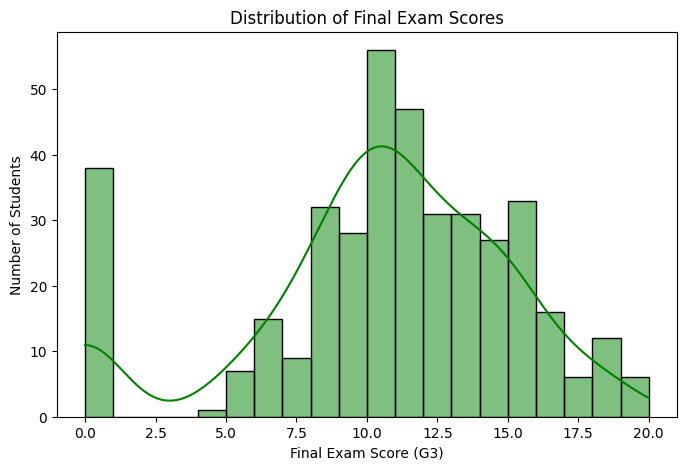

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['G3'], bins=20, kde=True, color='green')
#bins tells the python to divide the mark into 20groups
#kde: kernel density estimation, adds a smooth curve on the top of histogram

plt.title("Distribution of Final Exam Scores")
plt.xlabel("Final Exam Score (G3)")
plt.ylabel("Number of Students")

plt.show()

**Observation**

Most students scored in the middle range of the distribution.

Box Plot of G3
### Box Plot of Final Exam Scores

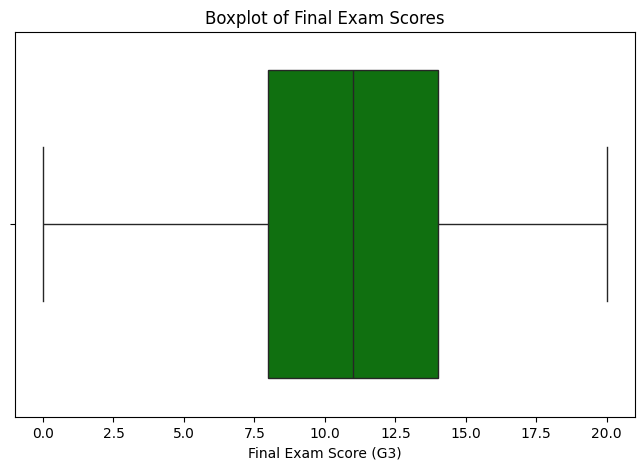

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['G3'],color='green')
plt.title("Boxplot of Final Exam Scores")
plt.xlabel("Final Exam Score (G3)")
plt.show()

Observation: The box plot shows that the final exam scores (G3)
range from approximately 0 to 20. The median score is around 11,
and 50% of the students scored between approximately 7 and 14.
No significant outliers were detected, indicating that the dataset
 does not contain extreme exam score values

Countplot of Study time

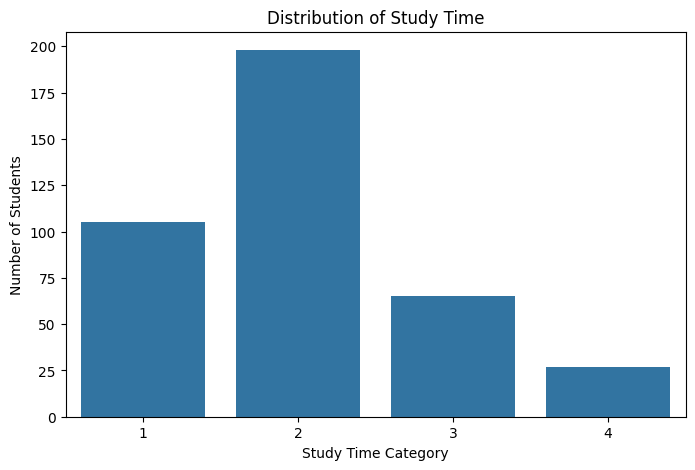

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(x='studytime', data=df)

plt.title("Distribution of Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

Countplot of failures

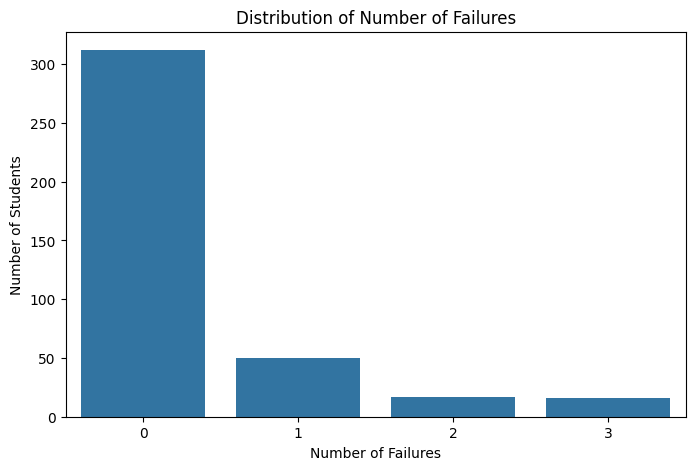

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(x='failures', data=df)

plt.title("Distribution of Number of Failures")
plt.xlabel("Number of Failures")
plt.ylabel("Number of Students")

plt.show()

Histogram of Age

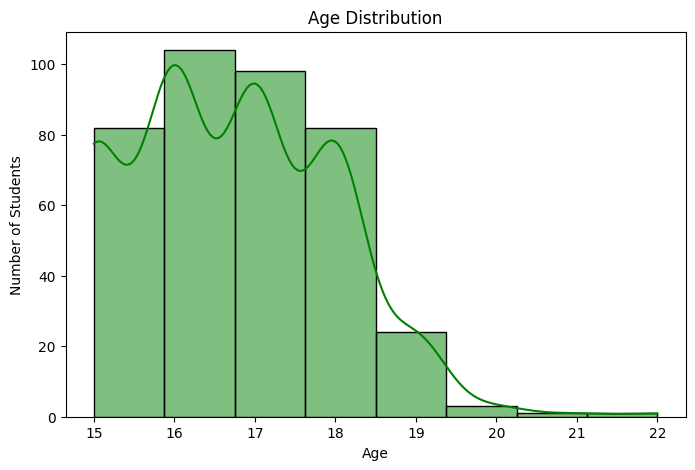

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=8, kde=True, color='green')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

Boxplot of absences

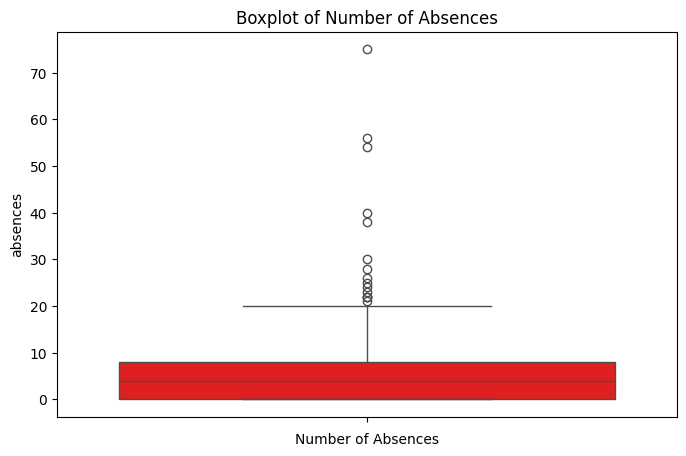

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(df['absences'],color='red')
plt.title("Boxplot of Number of Absences")
plt.xlabel("Number of Absences")
plt.show()


# Multivariate Analysis

A correlation heatmap was created to study the relationships among numerical variables.

In [41]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

Create a correlation matrix

In [42]:
numeric_df.corr()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
age,1.000000,-0.163658,-0.163438,0.070641,-0.004140,0.243665,0.053940,0.016434,0.126964,-0.062187,0.175230,-0.064081,-0.143474,-0.161579
Medu,-0.163658,1.000000,0.623455,-0.171639,0.064944,-0.236680,-0.003914,0.030891,0.064094,-0.046878,0.100285,0.205341,0.215527,0.217147
Fedu,-0.163438,0.623455,1.000000,-0.158194,-0.009175,-0.250408,-0.001370,-0.012846,0.043105,0.014742,0.024473,0.190270,0.164893,0.152457
traveltime,0.070641,-0.171639,-0.158194,1.000000,-0.100909,0.092239,-0.016808,-0.017025,0.028540,0.007501,-0.012944,-0.093040,-0.153198,-0.117142
studytime,-0.004140,0.064944,-0.009175,-0.100909,1.000000,-0.173563,0.039731,-0.143198,-0.063904,-0.075616,-0.062700,0.160612,0.135880,0.097820
failures,0.243665,-0.236680,-0.250408,0.092239,-0.173563,1.000000,-0.044337,0.091987,0.124561,0.065827,0.063726,-0.354718,-0.355896,-0.360415
famrel,0.053940,-0.003914,-0.001370,-0.016808,0.039731,-0.044337,1.000000,0.150701,0.064568,0.094056,-0.044354,0.022168,-0.018281,0.051363
freetime,0.016434,0.030891,-0.012846,-0.017025,-0.143198,0.091987,0.150701,1.000000,0.285019,0.075733,-0.058078,0.012613,-0.013777,0.011307
goout,0.126964,0.064094,0.043105,0.028540,-0.063904,0.124561,0.064568,0.285019,1.000000,-0.009577,0.044302,-0.149104,-0.162250,-0.132791
health,-0.062187,-0.046878,0.014742,0.007501,-0.075616,0.065827,0.094056,0.075733,-0.009577,1.000000,-0.029937,-0.073172,-0.097720,-0.061335


### heatmap

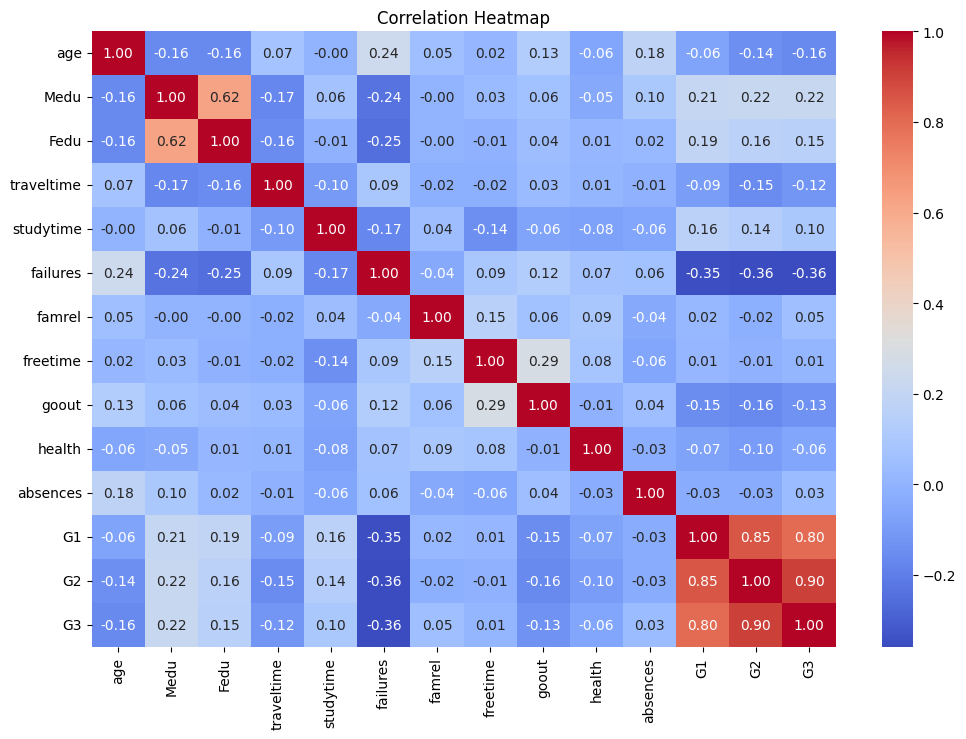

In [43]:

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,#Shows the actual correlation values inside each box.Without it, you'd only see colors
    cmap='coolwarm',#Chooses the color scheme.
    fmt=".2f"#Displays values with 2 decimal places
)

plt.title("Correlation Heatmap")
plt.show()

**Observation**

G1 and G2 showed the strongest positive correlation with G3.

#Bivariate Analaysis

###Study Time vs G3

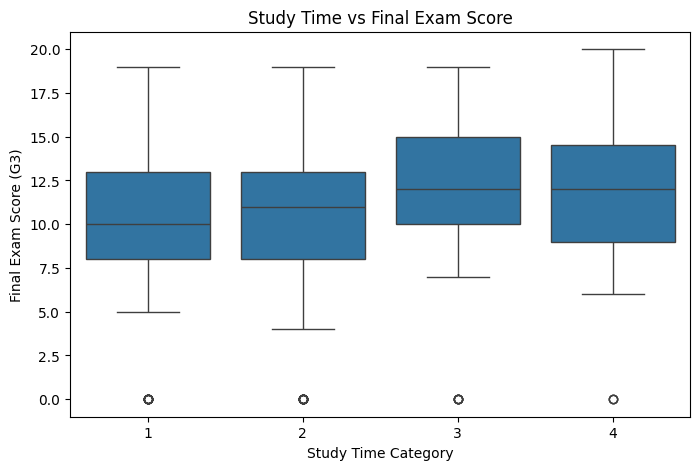

In [51]:

#comparing study time vs final exam score
plt.figure(figsize=(8,5))

sns.boxplot(x='studytime', y='G3', data=df)

plt.title("Study Time vs Final Exam Score")
plt.xlabel("Study Time Category")
plt.ylabel("Final Exam Score (G3)")

plt.show()

###Failures vs G3

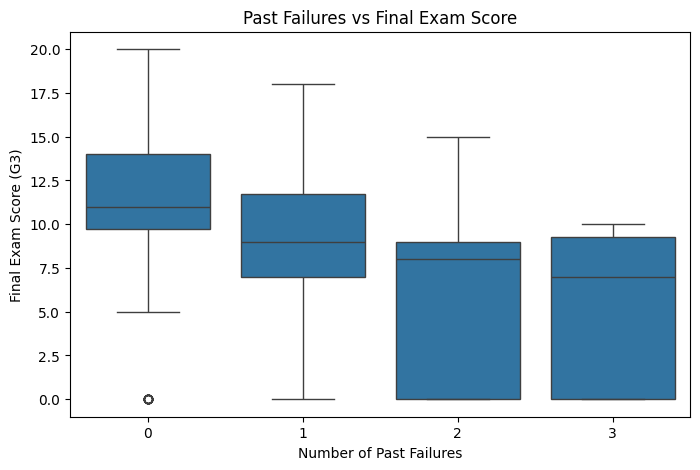

In [45]:
#comapring past failures vs final exam scores
plt.figure(figsize=(8,5))

sns.boxplot(x='failures', y='G3', data=df)

plt.title("Past Failures vs Final Exam Score")
plt.xlabel("Number of Past Failures")
plt.ylabel("Final Exam Score (G3)")

plt.show()

###Absences vs G3

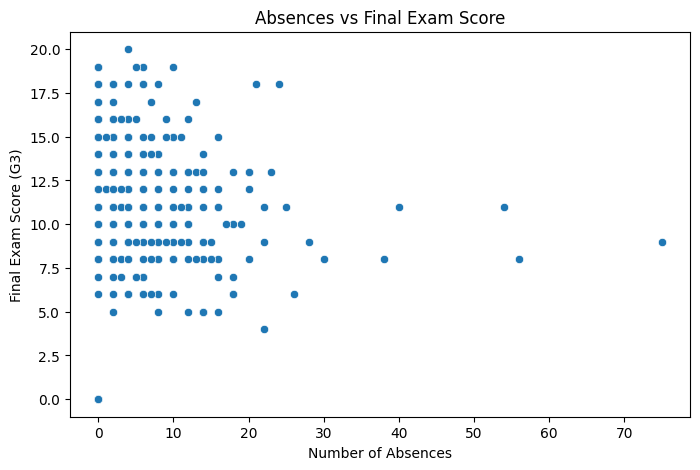

In [46]:
#comapring absences vs final exam scores
plt.figure(figsize=(8,5))

sns.scatterplot(x='absences', y='G3', data=df)

plt.title("Absences vs Final Exam Score")
plt.xlabel("Number of Absences")
plt.ylabel("Final Exam Score (G3)")

plt.show()

###G1 vs G3

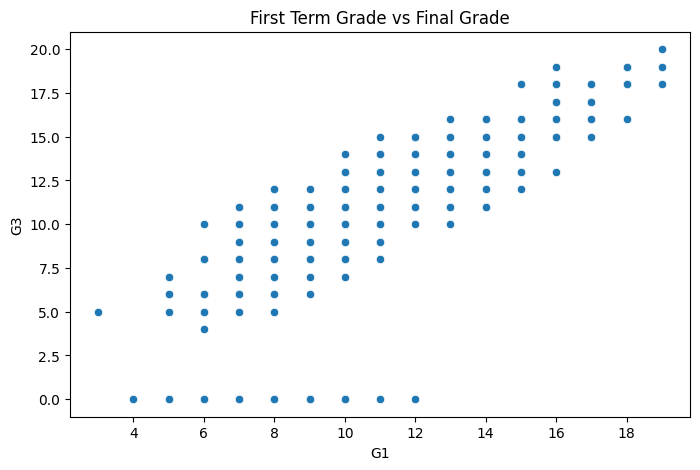

In [50]:
#G1 vs G3
plt.figure(figsize=(8,5))

sns.scatterplot(x='G1', y='G3', data=df)

plt.title("First Term Grade vs Final Grade")
plt.xlabel("G1")
plt.ylabel("G3")

plt.show()

###G2 vs G3

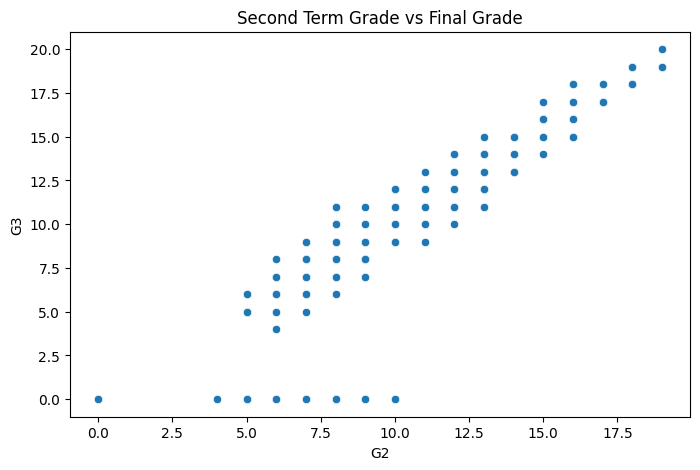

In [49]:
#G2 vs G3
plt.figure(figsize=(8,5))

sns.scatterplot(x='G2', y='G3', data=df)

plt.title("Second Term Grade vs Final Grade")
plt.xlabel("G2")
plt.ylabel("G3")

plt.show()

# Step 6: Data Preprocessing

Categorical variables were converted into numerical values using Label Encoding.

In [52]:
#Data preprocessing for Machine Learning
df.dtypes

,0
sex,object
age,int64
address,object
Medu,int64
Fedu,int64
traveltime,int64
studytime,int64
failures,int64
schoolsup,object
famsup,object


In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
label_encoder = LabelEncoder()

In [55]:
categorical_columns = [
    'sex',
    'address',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'higher',
    'internet'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [56]:
df.head(6)

,sex,age,address,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,...,higher,internet,famrel,freetime,goout,health,absences,G1,G2,G3
0,0,18,1,4,4,2,2,0,1,0,...,1,0,4,3,4,3,6,5,6,6
1,0,17,1,1,1,1,2,0,0,1,...,1,1,5,3,3,3,4,5,5,6
2,0,15,1,1,1,1,2,3,1,0,...,1,1,4,3,2,3,10,7,8,10
3,0,15,1,4,2,1,3,0,0,1,...,1,1,3,2,2,5,2,15,14,15
4,0,16,1,3,3,1,2,0,0,1,...,1,0,4,3,2,5,4,6,10,10
5,1,16,1,4,3,1,2,0,0,1,...,1,1,5,4,2,5,10,15,15,15


In [58]:
df.dtypes

,0
sex,int64
age,int64
address,int64
Medu,int64
Fedu,int64
traveltime,int64
studytime,int64
failures,int64
schoolsup,int64
famsup,int64


Observation: The dataset contained 8 categorical features. These were converted into numerical values using Label Encoding, making the dataset suitable for machine learning algorithms that require numerical input

# Step 7: Feature Selection

The dataset was divided into input features (X) and target variable (y).

Separate Features (X) and Target(Y)

In [60]:
X = df.drop('G3', axis=1)
y = df['G3']

In [61]:
print(X.head())

   sex  age  address  Medu  Fedu  traveltime  studytime  failures  schoolsup  \
0    0   18        1     4     4           2          2         0          1   
1    0   17        1     1     1           1          2         0          0   
2    0   15        1     1     1           1          2         3          1   
3    0   15        1     4     2           1          3         0          0   
4    0   16        1     3     3           1          2         0          0   

   famsup  ...  activities  higher  internet  famrel  freetime  goout  health  \
0       0  ...           0       1         0       4         3      4       3   
1       1  ...           0       1         1       5         3      3       3   
2       0  ...           0       1         1       4         3      2       3   
3       1  ...           1       1         1       3         2      2       5   
4       1  ...           0       1         0       4         3      2       5   

   absences  G1  G2  
0         

In [62]:
print(y.head())

0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


# Step 8: Train-Test Split

The dataset was split into 80% training data and 20% testing data.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [64]:
#check shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(316, 21)
(79, 21)
(316,)
(79,)


Observation: The dataset was divided into training and testing sets using an 80:20 ratio. The training set was used to train the Linear Regression model, while the testing set was reserved to evaluate its performance on unseen data.

# Step 9: Model Building

A Linear Regression model was trained using the training dataset.

In [65]:
#Using Linear Regression algo to train our model
from sklearn.linear_model import LinearRegression

Create the Model

In [67]:
#Creating Model
model = LinearRegression()

Train the Model

In [68]:
#TRain the model
model.fit(X_train, y_train)

LinearRegression()

# Step 10: Prediction

The trained model was used to predict exam scores for the testing dataset.

In [69]:
y_pred = model.predict(X_test)

In [70]:
X_test

,sex,age,address,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,...,activities,higher,internet,famrel,freetime,goout,health,absences,G1,G2
78,1,17,1,2,1,2,1,3,1,1,...,1,0,1,4,5,1,3,2,8,8
371,1,18,0,1,2,3,1,0,0,1,...,1,0,1,4,3,3,3,3,14,12
248,1,18,0,3,3,1,2,1,0,1,...,0,1,1,4,3,3,5,8,3,5
55,0,16,1,2,1,1,2,0,0,0,...,1,1,1,5,3,4,2,8,8,9
390,1,20,1,2,2,1,2,2,0,1,...,0,1,0,5,5,4,4,11,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
364,0,17,0,1,2,2,2,0,0,0,...,0,1,0,3,2,2,3,0,12,11
82,0,15,1,3,2,1,2,0,0,1,...,0,1,1,4,4,4,5,10,7,6
114,1,15,0,2,1,1,2,0,0,0,...,1,1,1,5,4,2,5,8,9,9
3,0,15,1,4,2,1,3,0,0,1,...,1,1,1,3,2,2,5,2,15,14


In [72]:
y_pred

array([ 6.02306919, 11.77979634,  3.33705471,  8.46406493,  8.58958002,
       12.65336313, 18.8306108 ,  7.41959581,  6.82254027, 12.68184941,
       14.80699671,  5.63254273, 13.65694262, 11.55253364, 14.64521123,
        8.65820709,  6.71495855, 10.97380056, 14.64761866,  8.08638291,
       14.27821542, 16.26383172, 15.17600681,  5.54296491,  8.34649673,
       20.21196061, 10.79515417,  8.78154909, 16.9426821 , 10.90560714,
        9.54637423,  7.06032371, 14.96704888, 12.37475997,  6.00575549,
        5.02397581, -2.7987572 , 14.84882969, 12.28211803,  6.65997585,
        5.58036348, 10.32311383, 14.13315725,  7.03759118, 16.31149514,
        9.65625577, 11.81347442, 14.15039755, 12.05211714, 16.07290696,
       13.92762098, 14.44672717, 10.83723987,  7.4745348 ,  3.5944946 ,
       12.78507941, 10.16849492,  6.62062833, 14.84273028, 16.13883454,
       12.90274242,  8.1702651 ,  6.92097842,  3.59047663,  4.0921704 ,
       16.79383986,  7.68372474,  9.20218628,  9.12262107, 15.77

Compare Actual vs Predicted


In [73]:
results = pd.DataFrame({
    'Actual Score': y_test,
    'Predicted Score': y_pred
})

results.head(10)

,Actual Score,Predicted Score
78,10,6.023069
371,12,11.779796
248,5,3.337055
55,10,8.464065
390,9,8.589580
223,13,12.653363
42,18,18.830611
234,6,7.419596
316,0,6.822540
116,14,12.681849


# Step 11: Model Evaluation

The model was evaluated using regression evaluation metrics.

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

1. Mean Absolute Error (MAE)
It tells us the average prediction error

In [75]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.4471820873663974


2. Mean Squared Error (MSE)
Why square the errors?

If one prediction is very wrong, we want to penalize it more.

In [76]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 4.9269234385285


3. Root Mean Squared Error (RMSE)
RMSE is simply the square root of MSE.

It tells you the prediction error in the same unit as the target (exam marks).

In [77]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 2.2196674161974133


4. R² Score (Coefficient of Determination)

In [78]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7597214298451508


Observation: The Linear Regression model achieved an R² score of 0.75, which indicates that the model explains approximately 75% of the variation in students' final exam scores. This suggests that the model has good predictive performance and can make reasonably accurate exam score predictions

#STEP 12: Actual vs Predicted Graph

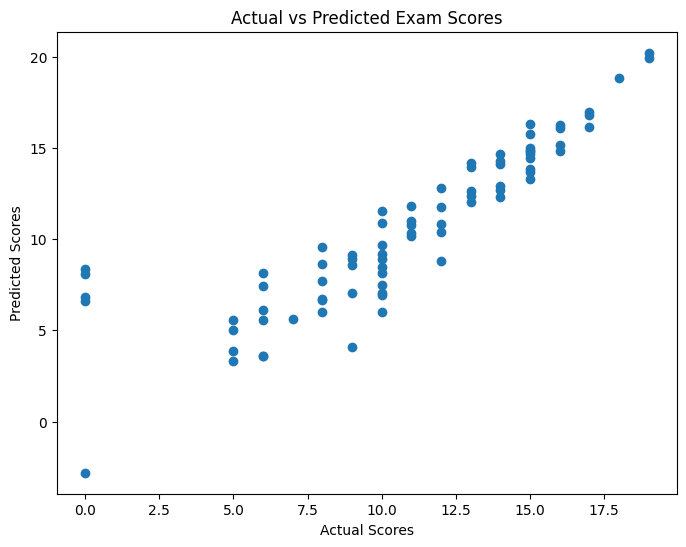

In [80]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

# Conclusion

The objective of this project was to predict students' final exam scores using Linear Regression.

The dataset was cleaned, analyzed using EDA, preprocessed, and used to train a machine learning model.

The model achieved an R² score of approximately 0.75, demonstrating good predictive performance and the ability to estimate students' final exam scores with reasonable accuracy.